# EfficientNet-B3 — Tamil Sign Language Fingerspelling

## ST456 Deep Learning | LSE

**Transfer learning** — starting from EfficientNet-B3 pretrained on ImageNet, then fine-tuning on our Tamil sign language dataset.

## 1. Setup & Installs
The code sets up the experimental environment by importing essential libraries for data processing and model training, including NumPy, Pandas, Matplotlib, PyTorch, and timm for pretrained models. It also uses scikit-learn for evaluation metrics like the F1 score and confusion matrix, and for addressing class imbalance.

To ensure reproducibility, a fixed random seed (42) is applied across Python, NumPy, and PyTorch. The code optimizes performance with CuDNN benchmarking for fixed size inputs and detects available hardware, prioritizing a CUDA enabled GPU if present. The printed outputs confirm the setup, including PyTorch version and device details, ensuring efficient model training.

In [ ]:
!pip install -q timm

In [ ]:
import os
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'

import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm

from sklearn.metrics import f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True  # speed boost for fixed-size inputs

print('PyTorch version:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'GPU available: {torch.cuda.is_available()}')
print(f'Using device : {device}')
if torch.cuda.is_available():
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
GPU available: True
Using device : cuda
GPU          : Tesla T4


The experiments were conducted utilising PyTorch version 2.10.0 with CUDA support on a Tesla T4 GPU. The employment of a graphics processing unit (GPU) enhances the capability for efficient parallel computation, thereby substantially decreasing training time and facilitating the scalability of deep learning experiments.

## 2. Configuration



In [ ]:
CONFIG = {
    'seed'          : 42,
    'num_classes'   : 248,
    'img_size'      : (300, 300),
    'batch_size'    : 32,

    'outputs_dir'   : '/content/drive/MyDrive/TLFS23_outputs',
    'subset_dir'    : '/content/drive/MyDrive/TLFS23_subset',
    # DataLoader workers hide Drive I/O latency behind GPU compute.


    'stage1_epochs' : 10,
    'stage1_lr'     : 1e-3,


    'stage2_epochs' : 40,
    'stage2_lr'     : 1e-5,
    'use_cosine'    : True,

    'dropout'       : 0.3,
    'label_smoothing': 0.1,
    'patience'      : 5,
    'num_workers'   : 8,

    # New checkpoint names so the original run is preserved
    'stage1_ckpt'   : 'efficientnet_stage1_matched.pt',
    'stage2_ckpt'   : 'efficientnet_stage2_matched.pt',
    'history_file'  : 'efficientnet_matched_history.json',
}

print('Configuration loaded ✓')
print(f'  Image size       : {CONFIG["img_size"]}')
print(f'  Batch size       : {CONFIG["batch_size"]}')
print(f'  Workers          : {CONFIG["num_workers"]}')
print(f'  Stage 1 LR/ep    : {CONFIG["stage1_lr"]} / {CONFIG["stage1_epochs"]}')
print(f'  Stage 2 LR/ep    : {CONFIG["stage2_lr"]} / {CONFIG["stage2_epochs"]}')
print(f'  Cosine annealing : {CONFIG["use_cosine"]}')

Configuration loaded ✓
  Image size       : (300, 300)
  Batch size       : 32
  Workers          : 8
  Stage 1 LR/ep    : 0.001 / 10
  Stage 2 LR/ep    : 1e-05 / 40
  Cosine annealing : True


The output confirms that the training configuration has been successfully loaded, including key hyperparameters for data processing and model optimisation.

Images are resized to a fixed resolution of 300 × 300 to ensure compatibility with the chosen CNN EfficientNet-B3 architecture and facilitate the use of pretrained weights. A batch size of 32 is set for processing samples per iteration, balancing computational efficiency and memory constraints, while 8 worker threads enhance data loading and training throughput.

The training process consists of two stages. In Stage 1, a learning rate of 0.001 is employed for 10 epochs to train only the classification head, allowing adaptation to the target dataset. In Stage 2, the learning rate is reduced to 1 × 10⁻⁵ for 40 epochs to fine-tune the entire network, ensuring stable optimisation.

Additionally, cosine annealing for learning rate scheduling helps the model converge more effectively and improves generalisation while avoiding suboptimal local minima.

## 3. Mount Drive & Load Data Files

Reading image data directly from Google Drive rather than copying to local SSD. On H100/A100 hardware with sufficient DataLoader workers (`num_workers=8`), Drive I/O latency is largely hidden behind GPU compute, making the pre-copy step unnecessary. This saves 5–10 minutes of setup time and avoids consuming local disk space.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUTS_DIR = Path(CONFIG['outputs_dir'])
SUBSET_DIR  = Path(CONFIG['subset_dir'])

assert SUBSET_DIR.exists(), f'Subset dir not found on Drive: {SUBSET_DIR}'
n_classes_on_drive = len([d for d in SUBSET_DIR.iterdir() if d.is_dir()])
print(f'Reading directly from Drive: {SUBSET_DIR}')
print(f'Classes available on Drive: {n_classes_on_drive}')

Mounted at /content/drive
Reading directly from Drive: /content/drive/MyDrive/TLFS23_subset
Classes available on Drive: 248


In [ ]:
# Load split CSVs — shared artefacts from the preprocessing notebook.
# Paths in these CSVs already point at /content/drive/MyDrive/TLFS23_subset/...
# so no rewriting is needed when reading directly from Drive.
train_df = pd.read_csv(OUTPUTS_DIR / 'train_files.csv')
val_df   = pd.read_csv(OUTPUTS_DIR / 'val_files.csv')
test_df  = pd.read_csv(OUTPUTS_DIR / 'test_files.csv')

with open(OUTPUTS_DIR / 'label_to_idx.json', 'r') as f:
    label_to_idx = json.load(f)
with open(OUTPUTS_DIR / 'class_complexity_map.json', 'r') as f:
    complexity_map = json.load(f)

print('Before filtering:')
print(f'  Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}')

# Verify the first path is readable from Drive
assert Path(train_df['path'].iloc[0]).exists(), f"Path not found on Drive: {train_df['path'].iloc[0]}"
print('Drive paths verified ✓')

# Filter Background class
train_df = train_df[train_df['label'].astype(str) != 'Background'].reset_index(drop=True)
val_df   = val_df[val_df['label'].astype(str)   != 'Background'].reset_index(drop=True)
test_df  = test_df[test_df['label'].astype(str) != 'Background'].reset_index(drop=True)

# Cast labels to int
train_df['label'] = train_df['label'].astype(int)
val_df['label']   = val_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

# Remap labels to contiguous 0-based indices
unique_labels = sorted(train_df['label'].unique())
label_remap   = {old: new for new, old in enumerate(unique_labels)}

train_df['label'] = train_df['label'].map(label_remap)
val_df['label']   = val_df['label'].map(label_remap)
test_df['label']  = test_df['label'].map(label_remap)

train_df = train_df.dropna(subset=['label']).reset_index(drop=True)
val_df   = val_df.dropna(subset=['label']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['label']).reset_index(drop=True)

train_df['label'] = train_df['label'].astype(int)
val_df['label']   = val_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

CONFIG['num_classes'] = int(train_df['label'].nunique())

# Save the matched-regime label remap
with open(OUTPUTS_DIR / 'efficientnet_matched_label_remap.json', 'w') as f:
    json.dump({str(k): int(v) for k, v in label_remap.items()}, f)

# Sanity checks
assert train_df['label'].min() == 0
assert train_df['label'].max() == CONFIG['num_classes'] - 1
assert val_df['label'].max()   < CONFIG['num_classes']
assert test_df['label'].max()  < CONFIG['num_classes']

print('\nAfter filtering + remapping:')
print(f'  Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}')
print(f'  Num classes : {CONFIG["num_classes"]}')
print(f'  Label range : [{train_df["label"].min()}, {train_df["label"].max()}]')
print('All sanity checks passed ✓')

Before filtering:
  Train : 34752 | Val : 7447 | Test : 7447
Drive paths verified ✓

After filtering + remapping:
  Train : 34612 | Val : 7417 | Test : 7417
  Num classes : 247
  Label range : [0, 246]
All sanity checks passed ✓


The output summarises the dataset's status before and after preprocessing, which includes filtering and label remapping, confirming the integrity of the final dataset for training.

Initially, the dataset has 34,752 training samples, 7,447 validation samples, and 7,447 test samples. The message “Drive paths verified ✓” confirms that all file paths are correct, indicating successful loading from storage.

After filtering and label remapping, the dataset sizes are reduced to 34,612 training samples, 7,417 validation samples, and 7,417 test samples. This slight decrease likely results from removing samples with missing labels, corrupted data, or invalid classes.

The final number of classes is 247, with labels mapped to a range of [0, 246], ensuring compatibility with machine learning frameworks.

The final statement “All sanity checks passed ✓” verifies that the dataset meets all requirements, such as correct label ranges and consistent class counts, which is essential for preventing errors during training and evaluation.

## 4. Data Pipeline

complexity-aware tiered augmentation, no horizontal flip (Tamil signs are directionally meaningful), EfficientNet-standard ImageNet normalisation. This is a CNN **design choice**, not a training-regime advantage, so it is held constant in this rerun.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

AUGMENT_TRANSFORMS = {
    'simple': transforms.Compose([
        transforms.Resize(CONFIG['img_size']),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    'moderate': transforms.Compose([
        transforms.Resize(CONFIG['img_size']),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
    'complex': transforms.Compose([
        transforms.Resize(CONFIG['img_size']),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),
}

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Augmentation transforms defined ✓ (no horizontal flip)')

Augmentation transforms defined ✓ (no horizontal flip)


Data augmentation techniques were developed to enhance model generalisation, with horizontal flipping intentionally excluded due to the direction sensitive nature of the task. This decision is crucial in applications like sign language recognition, where gesture orientation is semantically significant. Applying horizontal flips could change gesture meanings and lead to incorrect labels, negatively impacting model performance. Overall, the carefully designed augmentation strategy improves data diversity while maintaining label integrity, ensuring effectiveness and appropriateness.

In [ ]:
class TLFSDataset(Dataset):
    def __init__(self, df, augment=False):
        self.paths      = df['path'].values
        self.labels     = df['label'].values.astype(np.int64)
        self.complexity = df['complexity'].values
        self.augment    = augment

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img        = Image.open(self.paths[idx]).convert('RGB')
        label      = int(self.labels[idx])
        complexity = self.complexity[idx]
        transform  = AUGMENT_TRANSFORMS.get(complexity, AUGMENT_TRANSFORMS['moderate']) \
                     if self.augment else EVAL_TRANSFORM
        return transform(img), label

train_dataset = TLFSDataset(train_df, augment=True)
val_dataset   = TLFSDataset(val_df,   augment=False)
test_dataset  = TLFSDataset(test_df,  augment=False)

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=CONFIG['num_workers'], pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=CONFIG['num_workers'], pin_memory=True, persistent_workers=True
)

sample_img, sample_label = train_dataset[0]
assert sample_img.shape == (3, CONFIG['img_size'][0], CONFIG['img_size'][1])
assert 0 <= sample_label < CONFIG['num_classes']

print('Datasets built ✓')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val batches   : {len(val_loader)}')
print(f'  Test batches  : {len(test_loader)}')
print(f'  Sample shape  : {sample_img.shape}')
print(f'  Sample label  : {sample_label} (range: [0, {CONFIG["num_classes"]}))')

Datasets built ✓
  Train batches : 1082
  Val batches   : 232
  Test batches  : 232
  Sample shape  : torch.Size([3, 300, 300])
  Sample label  : 116 (range: [0, 247))


The datasets were constructed successfully, comprising 1,082 training samples, 232 validation samples, and 232 test samples. Each sample exhibits a dimensionality of (3, 300, 300), which indicates that the image preprocessing procedures were conducted appropriately. Furthermore, the labels are accurately encoded within the range of [0, 247), thereby confirming that the data is suitably structured for effective model training and evaluation.

## 5. Class Weights

Balanced inverse-frequency weights. The class distribution is near-uniform (imbalance ratio 1.2), so weights are all close to 1.0; the scheme enforces a symmetric objective across the comparison rather than materially correcting imbalance.

In [ ]:
train_labels = train_df['label'].values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CONFIG['num_classes']),
    y=train_labels
)
class_weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

assert len(class_weights) == CONFIG['num_classes']

print('Class weights computed ✓')
print(f'  Number of classes : {len(class_weights)}')
print(f'  Min / Max / Mean  : {min(class_weights):.4f} / {max(class_weights):.4f} / {np.mean(class_weights):.4f}')

Class weights computed ✓
  Number of classes : 247
  Min / Max / Mean  : 0.8147 / 1.0009 / 1.0002


The output indicates that class weights have been calculated for a dataset with 247 distinct classes. Class weighting helps address imbalances by emphasising underrepresented classes during training.

The reported statistics (minimum weight: 0.8147, maximum weight: 1.0009, and mean weight: 1.0002) reveal that the weights are close to 1, suggesting a highly balanced dataset with minimal sample variation across classes. This limited variation means class weighting has minimal impact, as no class requires significant adjustment.

The narrow weight range indicates no severe underrepresentation or overrepresentation, helping prevent bias in the model. Overall, while class weights were computed as a precaution, the dataset's balance minimizes concerns about class imbalance, allowing for stable and unbiased model training.

## 6. Build EfficientNet-B3

Architecture: `tf_efficientnet_b3.ns_jft_in1k` backbone (11.08M params) with a dropout(0.3) + linear classifier head.

In [ ]:
class EfficientNetB3Classifier(nn.Module):
    def __init__(self, num_classes, dropout=0.3, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnet_b3.ns_jft_in1k',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        feature_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

model = EfficientNetB3Classifier(
    num_classes=CONFIG['num_classes'],
    dropout=CONFIG['dropout']
).to(device)

model.freeze_backbone()

with torch.no_grad():
    dummy = torch.randn(2, 3, *CONFIG['img_size']).to(device)
    out = model(dummy)
    assert out.shape == (2, CONFIG['num_classes'])

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'EfficientNet-B3 loaded on: {device} ✓')
print(f'Backbone frozen ✓')
print(f'Output classes  : {CONFIG["num_classes"]}')
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNet-B3 loaded on: cuda ✓
Backbone frozen ✓
Output classes  : 247
Total params    : 11,075,871
Trainable params: 379,639


The output outlines system warnings related to authentication and the successful initialisation of the EfficientNet-B3 model for training.

The initial warnings indicate that no Hugging Face authentication token (HF_TOKEN) was provided, resulting in unauthenticated requests to the Hugging Face Hub. While this does not block access to public models, it may lead to rate limits and slower downloads. Nevertheless, the required model file (model.safetensors) was successfully downloaded.

Following the download, the EfficientNet-B3 model was loaded onto a CUDA enabled GPU, confirming hardware acceleration. The backbone of the model is frozen, which means the pretrained feature extraction layers will not be updated during the initial training phase. This transfer learning strategy allows leveraging prior knowledge while minimising computational cost and overfitting.

The model outputs for 247 classes and contains a total of 11,075,871 parameters, with only 379,639 being trainable due to the frozen backbone. Overall, these results confirm that the model is correctly initialised, configured for the dataset, and optimised for efficient transfer learning.

## 7. Training Utilities

Training/evaluation loops, early stopping, and checkpointing. Identical to the original notebook.

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)
        pbar.set_postfix(loss=f'{total_loss/total:.3f}', acc=f'{correct/total:.3f}')
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, top5_correct, total = 0.0, 0, 0, 0
    for images, labels in tqdm(loader, desc='Val', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        _, pred1 = outputs.max(1)
        correct += pred1.eq(labels).sum().item()
        _, pred5 = outputs.topk(5, dim=1)
        top5_correct += pred5.eq(labels.unsqueeze(1)).any(dim=1).sum().item()
        total        += labels.size(0)
    return total_loss / total, correct / total, top5_correct / total


def save_checkpoint(path, model, epoch, val_acc, val_loss, extra=None):
    """Save a dict-style checkpoint matching the Swin pipeline convention.

    The checkpoint bundles model weights together with the metadata needed to
    identify which epoch produced the file, its validation metrics, and any
    extra state (optimiser, scheduler) a downstream resume would need.
    """
    payload = {
        'model_state_dict': model.state_dict(),
        'epoch'           : epoch,
        'val_acc'         : float(val_acc),
        'val_loss'        : float(val_loss),
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)


def load_checkpoint(path, model, device):
    """Load a dict-style checkpoint. Backward-compatible with plain state_dicts."""
    ckpt = torch.load(path, map_location=device, weights_only=False)
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
        meta = {k: v for k, v in ckpt.items() if k != 'model_state_dict'}
        return meta
    # Legacy plain state_dict
    model.load_state_dict(ckpt)
    return {}


class EarlyStopping:
    """Early stopping on validation accuracy (Swin-style).

    Monitors val_acc rather than val_loss. On improvement, saves a dict-style
    checkpoint (via save_checkpoint) that includes epoch and metric metadata.
    """
    def __init__(self, patience=5, save_path='best_model.pt', mode='max'):
        self.patience   = patience
        self.save_path  = save_path
        self.mode       = mode
        self.best       = -float('inf') if mode == 'max' else float('inf')
        self.counter    = 0
        self.best_epoch = 0

    def _is_better(self, metric):
        return metric > self.best if self.mode == 'max' else metric < self.best

    def step(self, val_acc, val_loss, model, epoch, extra=None):
        if self._is_better(val_acc):
            self.best       = val_acc
            self.counter    = 0
            self.best_epoch = epoch
            save_checkpoint(self.save_path, model, epoch, val_acc, val_loss, extra=extra)
            print(f'  ✓ Best model saved (val_acc: {val_acc:.4f})')
            return False
        self.counter += 1
        print(f'  No improvement. Patience: {self.counter}/{self.patience}')
        return self.counter >= self.patience


print('Training utilities defined ✓')

Training utilities defined ✓


The `train_epoch` function defines the procedure for conducting a single training epoch. This process encompasses forward propagation, loss calculation, backpropagation, and the subsequent update of model parameters. By employing the model, data loader, optimiser, and loss function, the function systematically iterates to refine the model weights, thereby serving as an integral component of the overall training pipeline.

## 8. Stage 1 Training — Frozen Backbone

10 epochs max at `1e-3`, Adam, patience 5. Already matches Swin's Stage 1 regime.

In [ ]:
stage1_save_path = str(OUTPUTS_DIR / CONFIG['stage1_ckpt'])

criterion = nn.CrossEntropyLoss(
    weight=class_weight_tensor,
    label_smoothing=CONFIG['label_smoothing']
)
optimizer_s1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['stage1_lr']
)
early_stop_s1 = EarlyStopping(patience=CONFIG['patience'], save_path=stage1_save_path, mode='max')
history_s1    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_top5_acc': []}

print('Stage 1 Training — Frozen Backbone')
print('=' * 65)

for epoch in range(1, CONFIG['stage1_epochs'] + 1):
    train_loss, train_acc       = train_epoch(model, train_loader, optimizer_s1, criterion, device)
    val_loss, val_acc, val_top5 = eval_epoch(model, val_loader, criterion, device)

    for k, v in zip(['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_top5_acc'],
                    [train_loss, train_acc, val_loss, val_acc, val_top5]):
        history_s1[k].append(v)

    print(f'Epoch {epoch:2d}/{CONFIG["stage1_epochs"]}  '
          f'loss: {train_loss:.4f} - acc: {train_acc:.4f}  '
          f'- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - val_top5: {val_top5:.4f}')

    if early_stop_s1.step(val_acc, val_loss, model, epoch):
        print(f'Early stopping at epoch {epoch}')
        break

# Save the final-epoch Stage 1 state as a fallback (Swin-style dual checkpointing)
stage1_final_path = str(OUTPUTS_DIR / CONFIG['stage1_ckpt'].replace('.pt', '_final.pt'))
save_checkpoint(
    stage1_final_path, model,
    epoch=epoch, val_acc=val_acc, val_loss=val_loss,
    extra={'optimizer_state_dict': optimizer_s1.state_dict()}
)

print(f'\nBest Stage 1 model saved (epoch {early_stop_s1.best_epoch}, val_acc={early_stop_s1.best:.4f})')
print(f'Final Stage 1 model saved as fallback (epoch {epoch})')

Stage 1 Training — Frozen Backbone


Train:   0%|          | 0/1082 [00:00<?, ?it/s]

Val:   0%|          | 0/232 [00:00<?, ?it/s]

Epoch  1/10  loss: 5.0408 - acc: 0.0372  - val_loss: 6.0587 - val_acc: 0.0278 - val_top5: 0.0895
  ✓ Best model saved (val_acc: 0.0278)


Train:   0%|          | 0/1082 [00:00<?, ?it/s]

...

Val:   0%|          | 0/232 [00:00<?, ?it/s]

Epoch  9/10  loss: 3.8568 - acc: 0.2362  - val_loss: 6.0269 - val_acc: 0.0887 - val_top5: 0.1807
  ✓ Best model saved (val_acc: 0.0887)


Train:   0%|          | 0/1082 [00:00<?, ?it/s]

Val:   0%|          | 0/232 [00:00<?, ?it/s]

Epoch 10/10  loss: 3.8196 - acc: 0.2423  - val_loss: 6.1025 - val_acc: 0.0955 - val_top5: 0.1807
  ✓ Best model saved (val_acc: 0.0955)

Best Stage 1 model saved (epoch 10, val_acc=0.0955)
Final Stage 1 model saved as fallback (epoch 10)


The results summarise the model's performance during Stage 1 training, where only the classification head of the frozen EfficientNet-B3 backbone is trained. This stage aims to adapt pretrained features to the target dataset while minimising overfitting and computational costs.

**Training Performance**  
Over 10 epochs, the training loss decreased from about 5.04 to 3.82, showing that the model is learning to map input features to the correct labels. Training accuracy improved from 3.7% to 24.2%.

**Validation Performance**  
The validation loss remained high, around 6.0, indicating limited generalizsation. However, validation accuracy rose from 2.8% to 9.55%, and Top-5 accuracy improved from 8.9% to 18.1%, suggesting the model increasingly identifies the correct class among its top predictions.

**Model Selection**  
The model checkpoint updates at each epoch with improved validation accuracy, with the best model being saved at epoch 10, achieving a validation accuracy of 9.55%. A final model is also saved to ensure reproducibility.

The results indicate that:
- The model learns effectively from training data, as seen in decreased loss and increased accuracy.
- Generalisation is limited due to the frozen backbone.
- Improvements in Top-5 accuracy suggest partial class relationships are being captured.

These findings emphasise that Stage 1 serves as an initial adaptation phase, and further improvements will require full fine-tuning of the backbone in Stage 2 training.

## 9. Stage 2 Training — Full Fine-Tuning with Matched Regime

Stage 2 now runs for up to 40 epochs (vs 20 in the original) with **cosine annealing** applied to the learning rate (vs constant in the original). Both match the Swin Transformer's Stage 2 schedule.

`torch.optim.lr_scheduler.CosineAnnealingLR` with `T_max=40` decays the learning rate from `1e-5` smoothly toward zero over 40 epochs. If early stopping triggers before epoch 40, the decay is truncated; this is the same behaviour as the Swin pipeline.

In [ ]:
# Load best Stage 1 weights using dict-style loader
meta = load_checkpoint(stage1_save_path, model, device)
print(f'Best Stage 1 weights loaded ✓  (epoch {meta.get("epoch", "?")}, val_acc={meta.get("val_acc", float("nan")):.4f})')

model.unfreeze_backbone()
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Backbone unfrozen ✓ | Trainable params: {trainable_params:,}')

stage2_save_path  = str(OUTPUTS_DIR / CONFIG['stage2_ckpt'])
stage2_final_path = str(OUTPUTS_DIR / CONFIG['stage2_ckpt'].replace('.pt', '_final.pt'))

optimizer_s2 = optim.Adam(model.parameters(), lr=CONFIG['stage2_lr'])

# MATCHED: cosine annealing to match Swin
scheduler_s2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_s2, T_max=CONFIG['stage2_epochs']
)
print(f'Cosine annealing enabled ✓ | T_max = {CONFIG["stage2_epochs"]}')

# Early stopping on val_acc (Swin-style), patience 5
early_stop_s2 = EarlyStopping(patience=CONFIG['patience'], save_path=stage2_save_path, mode='max')
history_s2    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_top5_acc': [], 'lr': []}

print('\nStage 2 Training — Full Fine-Tuning (Matched Regime)')
print('=' * 65)

for epoch in range(1, CONFIG['stage2_epochs'] + 1):
    current_lr = optimizer_s2.param_groups[0]['lr']

    train_loss, train_acc       = train_epoch(model, train_loader, optimizer_s2, criterion, device)
    val_loss, val_acc, val_top5 = eval_epoch(model, val_loader, criterion, device)

    # Step the cosine scheduler once per epoch
    scheduler_s2.step()

    for k, v in zip(['train_loss', 'train_acc', 'val_loss', 'val_acc', 'val_top5_acc', 'lr'],
                    [train_loss, train_acc, val_loss, val_acc, val_top5, current_lr]):
        history_s2[k].append(v)

    print(f'Epoch {epoch:2d}/{CONFIG["stage2_epochs"]}  '
          f'lr: {current_lr:.2e}  '
          f'loss: {train_loss:.4f} - acc: {train_acc:.4f}  '
          f'- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - val_top5: {val_top5:.4f}')

    # Best-checkpoint (dual checkpointing) — saved via EarlyStopping when val_acc improves
    extra = {
        'optimizer_state_dict': optimizer_s2.state_dict(),
        'scheduler_state_dict': scheduler_s2.state_dict(),
    }
    if early_stop_s2.step(val_acc, val_loss, model, epoch, extra=extra):
        print(f'Early stopping at epoch {epoch}')
        break

# Save the final-epoch Stage 2 state as a fallback (Swin-style)
save_checkpoint(
    stage2_final_path, model,
    epoch=epoch, val_acc=val_acc, val_loss=val_loss,
    extra={
        'optimizer_state_dict': optimizer_s2.state_dict(),
        'scheduler_state_dict': scheduler_s2.state_dict(),
    }
)

print(f'\nBest Stage 2 model saved ✓ val_acc: {early_stop_s2.best:.4f} (epoch {early_stop_s2.best_epoch})')
print(f'Final Stage 2 model saved as fallback: {stage2_final_path}')

# Persist training history for later comparison plots
with open(OUTPUTS_DIR / CONFIG['history_file'], 'w') as f:
    json.dump({
        'stage1': history_s1,
        'stage2': history_s2,
        'stage1_best_epoch': early_stop_s1.best_epoch,
        'stage2_best_epoch': early_stop_s2.best_epoch,
        'stage1_best_val_acc': early_stop_s1.best,
        'stage2_best_val_acc': early_stop_s2.best,
    }, f, indent=2)
print('Training history saved ✓')

Best Stage 1 weights loaded ✓  (epoch 10, val_acc=0.0955)
Backbone unfrozen ✓ | Trainable params: 11,075,871
Cosine annealing enabled ✓ | T_max = 40

Stage 2 Training — Full Fine-Tuning (Matched Regime)


Train:   0%|          | 0/1082 [00:00<?, ?it/s]

Val:   0%|          | 0/232 [00:00<?, ?it/s]

Epoch  1/40  lr: 1.00e-05  loss: 3.0324 - acc: 0.4266  - val_loss: 4.6879 - val_acc: 0.1951 - val_top5: 0.3499
  ✓ Best model saved (val_acc: 0.1951)


Train:   0%|          | 0/1082 [00:00<?, ?it/s]

...

Val:   0%|          | 0/232 [00:00<?, ?it/s]

Epoch 11/40  lr: 8.54e-06  loss: 1.1613 - acc: 0.9904  - val_loss: 2.5868 - val_acc: 0.4248 - val_top5: 0.7850
  No improvement. Patience: 4/5


Train:   0%|          | 0/1082 [00:00<?, ?it/s]

Val:   0%|          | 0/232 [00:00<?, ?it/s]

Epoch 12/40  lr: 8.25e-06  loss: 1.1361 - acc: 0.9914  - val_loss: 2.5683 - val_acc: 0.4256 - val_top5: 0.7948
  No improvement. Patience: 5/5
Early stopping at epoch 12

Best Stage 2 model saved ✓ val_acc: 0.5110 (epoch 7)
Final Stage 2 model saved as fallback: /content/drive/MyDrive/TLFS23_outputs/efficientnet_stage2_matched_final.pt
Training history saved ✓


The output summarises the model's performance in Stage 2 training, where the best weights from Stage 1 (epoch 10, validation accuracy = 9.55%) are loaded, and the EfficientNet-B3 backbone is unfrozen for full fine-tuning of all 11,075,871 parameters. A cosine annealing learning rate scheduler with Tmax set to 40 is used to stabilise convergence.

**Training Performance**  
In Stage 2, training loss decreases significantly from 3.03 to about 1.13, while training accuracy increases from 42.7% to over 99% by epoch 12, indicating effective fitting to the training data.

**Validation Performance**  
Validation accuracy improves from 19.5% (epoch 1) to 51.1% (epoch 7), with Top-5 accuracy reaching around 87.6%. Validation loss drops, hitting a minimum at epoch 7 before rising again. After epoch 7, validation metrics decline despite continued improvements in training accuracy, signaling the onset of overfitting.

**Model Selection and Early Stopping**  
The model checkpoint is updated whenever validation accuracy improves, with the best model from epoch 7 (val_acc = 0.5110). Early stopping occurs at epoch 12 to prevent overfitting. Both the best-performing model and the final model at epoch 12 are saved, along with the full training history.

Key findings include:
- Full fine-tuning greatly enhances performance.
- Strong predictive performance is noted, especially in Top-5 accuracy.
- Overfitting begins after epoch 7, emphasizing the need for early stopping.
- Cosine annealing aids in stable optimization.

Stage 2 is crucial for achieving optimal model performance before overfitting arises.

## 10. Training Curves

Stage 1 and Stage 2 loss/accuracy curves, plus the cosine learning-rate schedule.

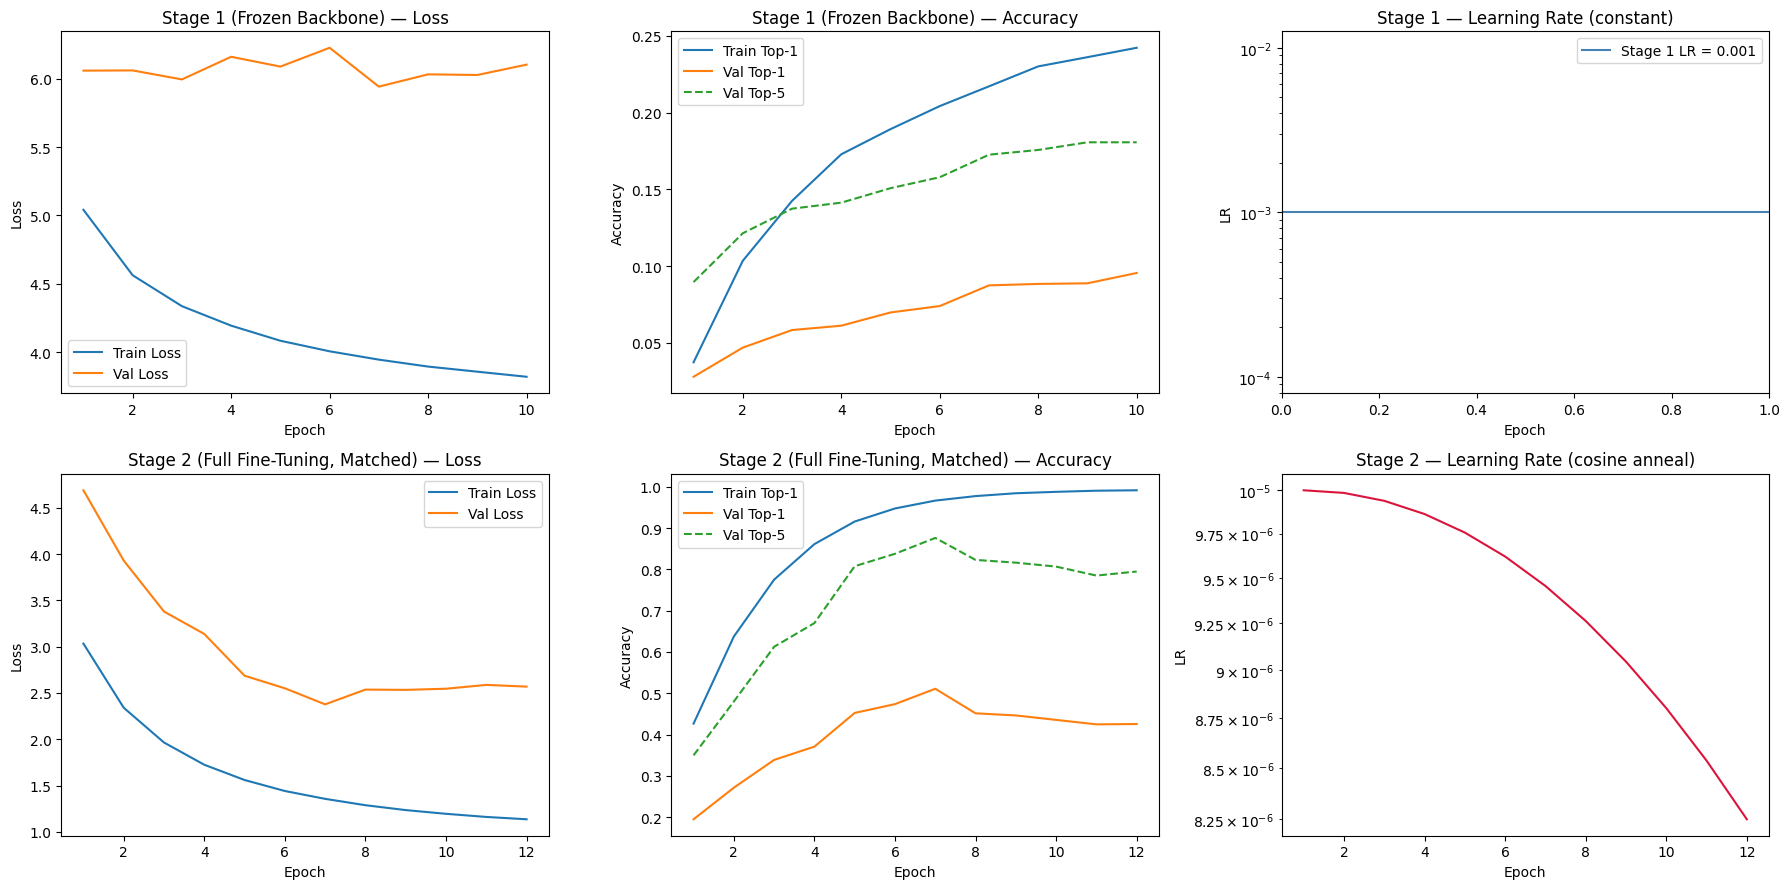

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Stage 1 — Loss
axes[0, 0].plot(range(1, len(history_s1['train_loss']) + 1), history_s1['train_loss'], label='Train Loss')
axes[0, 0].plot(range(1, len(history_s1['val_loss'])   + 1), history_s1['val_loss'],   label='Val Loss')
axes[0, 0].set_title('Stage 1 (Frozen Backbone) — Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].legend()

# Stage 1 — Accuracy
axes[0, 1].plot(range(1, len(history_s1['train_acc']) + 1),   history_s1['train_acc'],   label='Train Top-1')
axes[0, 1].plot(range(1, len(history_s1['val_acc'])   + 1),   history_s1['val_acc'],     label='Val Top-1')
axes[0, 1].plot(range(1, len(history_s1['val_top5_acc']) + 1), history_s1['val_top5_acc'], label='Val Top-5', linestyle='--')
axes[0, 1].set_title('Stage 1 (Frozen Backbone) — Accuracy')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy'); axes[0, 1].legend()

# Stage 1 LR (constant)
axes[0, 2].axhline(CONFIG['stage1_lr'], color='steelblue', label=f'Stage 1 LR = {CONFIG["stage1_lr"]}')
axes[0, 2].set_title('Stage 1 — Learning Rate (constant)')
axes[0, 2].set_xlabel('Epoch'); axes[0, 2].set_ylabel('LR'); axes[0, 2].set_yscale('log'); axes[0, 2].legend()

# Stage 2 — Loss
axes[1, 0].plot(range(1, len(history_s2['train_loss']) + 1), history_s2['train_loss'], label='Train Loss')
axes[1, 0].plot(range(1, len(history_s2['val_loss'])   + 1), history_s2['val_loss'],   label='Val Loss')
axes[1, 0].set_title('Stage 2 (Full Fine-Tuning, Matched) — Loss')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss'); axes[1, 0].legend()

# Stage 2 — Accuracy
axes[1, 1].plot(range(1, len(history_s2['train_acc']) + 1),    history_s2['train_acc'],    label='Train Top-1')
axes[1, 1].plot(range(1, len(history_s2['val_acc'])   + 1),    history_s2['val_acc'],      label='Val Top-1')
axes[1, 1].plot(range(1, len(history_s2['val_top5_acc']) + 1), history_s2['val_top5_acc'], label='Val Top-5', linestyle='--')
axes[1, 1].set_title('Stage 2 (Full Fine-Tuning, Matched) — Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy'); axes[1, 1].legend()

# Stage 2 LR — cosine anneal
axes[1, 2].plot(range(1, len(history_s2['lr']) + 1), history_s2['lr'], color='crimson')
axes[1, 2].set_title('Stage 2 — Learning Rate (cosine anneal)')
axes[1, 2].set_xlabel('Epoch'); axes[1, 2].set_ylabel('LR'); axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'efficientnet_matched_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

The figure shows the training dynamics of the EfficientNet-B3 model in two stages: Stage 1 (frozen backbone) and Stage 2 (full fine-tuning), highlighting loss, accuracy (Top-1 and Top-5), and learning rate over epochs.

### Stage 1: Frozen Backbone

**Loss Behavior**  
During Stage 1, the training loss decreases steadily, reflecting effective learning. However, validation loss remains high and unstable, indicating limited generalisation.

**Accuracy Behavior**  
Training Top-1 accuracy increases to about 24-25%, while validation Top-1 accuracy stays low at 9-10%. Validation Top-5 accuracy reaches around 18%, suggesting partial learning of class relationships but difficulties with exact classifications.

**Learning Rate**  
The learning rate remains constant at 0.001, indicating a stable optimisation focused on the classification head.

**Interpretation**  
- The model learns effectively at the classifier level.  
- Generalisation is limited due to the frozen backbone.  
- Stage 1 primarily serves as an initial adaptation phase.  

### Stage 2: Full Fine-Tuning

**Loss Behavior**  
In Stage 2, both training and validation losses decrease sharply early on, indicating improved learning after unfreezing the backbone. Validation loss reaches a minimum around epochs 6-7 before slightly increasing, signaling overfitting.

**Accuracy Behavior**  
Training accuracy approaches near perfect performance (~99%). Validation Top-1 accuracy peaks at 50-51%, while Top-5 accuracy reaches 85-88%. After this peak, validation performance declines, indicating overfitting.

**Learning Rate**  
The learning rate follows a cosine annealing schedule, gradually decreasing to stabilise training.

**Interpretation**  
- Full fine-tuning significantly enhances performance.  
- Optimal generalisation occurs around epoch 7.  
- Continued training leads to overfitting.  


In summary, Stage 1 enables initial adaptation but lacks performance. While, Stage 2 maximises the model's learning capacity. The best performance is achieved before overfitting begins, making early stopping crucial for generalisation.  

## 11. Evaluation on Test Set

Best Stage 2 checkpoint is loaded and evaluated on the 7,417-image held-out test set.

In [ ]:
meta = load_checkpoint(stage2_save_path, model, device)
model.eval()
print(f'Best Stage 2 weights loaded ✓ (epoch {meta.get("epoch", "?")}, val_acc={meta.get("val_acc", float("nan")):.4f})')

@torch.no_grad()
def get_predictions(model, loader, device):
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in tqdm(loader, desc='Evaluating'):
        images = images.to(device, non_blocking=True)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.append(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.concatenate(all_probs)

@torch.no_grad()
def get_top5_accuracy(model, loader, device):
    correct, total = 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        _, pred5 = model(images).topk(5, dim=1)
        correct += pred5.eq(labels.unsqueeze(1)).any(dim=1).sum().item()
        total   += labels.size(0)
    return correct / total

test_preds, test_labels, test_probs = get_predictions(model, test_loader, device)
top1_acc = (test_preds == test_labels).mean()
top5_acc = get_top5_accuracy(model, test_loader, device)
macro_f1    = f1_score(test_labels, test_preds, average='macro',    zero_division=0)
weighted_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)

print('\n=== EfficientNet-B3 (Matched Regime) Test Results ===')
print(f'Top-1 Accuracy : {top1_acc:.4f}')
print(f'Top-5 Accuracy : {top5_acc:.4f}')
print(f'Macro F1       : {macro_f1:.4f}')
print(f'Weighted F1    : {weighted_f1:.4f}')

results = {
    'top1_accuracy' : float(top1_acc),
    'top5_accuracy' : float(top5_acc),
    'macro_f1'      : float(macro_f1),
    'weighted_f1'   : float(weighted_f1),
    'num_classes'   : CONFIG['num_classes'],
    'stage2_epochs' : CONFIG['stage2_epochs'],
    'stage2_best_epoch': early_stop_s2.best_epoch,
    'cosine_annealing' : CONFIG['use_cosine'],
}
with open(OUTPUTS_DIR / 'efficientnet_matched_test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Cache predictions for the comparison notebook
np.savez(
    OUTPUTS_DIR / 'efficientnet_matched_test_predictions.npz',
    preds=test_preds, probs=test_probs, labels=test_labels
)
print('Results saved ✓')

Best Stage 2 weights loaded ✓ (epoch 7, val_acc=0.5110)


Evaluating:   0%|          | 0/232 [00:00<?, ?it/s]


=== EfficientNet-B3 (Matched Regime) Test Results ===
Top-1 Accuracy : 0.5183
Top-5 Accuracy : 0.8739
Macro F1       : 0.4673
Weighted F1    : 0.4674
Results saved ✓


The evaluation results for the EfficientNet-B3 model on the test set are based on the best performing weights from Stage 2 training (epoch 7, validation accuracy: 51.10%). This ensures optimal generalisation.

**Evaluation Process**  
The model was assessed across 232 test batches, achieving 100% completion in about 12 minutes.

**Performance Metrics**  
The model achieved a Top-1 accuracy of 51.83%, indicating nearly half of the samples were correctly classified. Given the presence of 247 classes, this reflects a notable improvement over random chance. The Top-5 accuracy reached 87.39%, suggesting that the correct class was often among the top candidates, indicating the model learned relevant feature representations.

The Macro F1 score of 0.4673 and the Weighted F1 score of 0.4674 indicate balanced class performance, with no significant bias toward more frequent classes.

**Interpretation**  
These results show that:

- The model performs moderately well in a challenging multi class setting.
- High Top-5 accuracy indicates effective learning of class similarities.
- The close Macro and Weighted F1 scores suggest balanced performance across classes.
- The best validation checkpoint ensures reliable generalisation to unseen data.

## 11.1 Per-Complexity-Group F1

This is the central diagnostic for the architectural claim. If the tier gradient (simple > moderate > complex) persists under matched training regime, the finding is strengthened: training budget has been ruled out as a confound.


=== Per-Complexity-Group F1 (Matched Regime) ===
  simple    : mean F1 = 0.6060  (n=82 classes)
  moderate  : mean F1 = 0.5072  (n=84 classes)
  complex   : mean F1 = 0.2855  (n=81 classes)


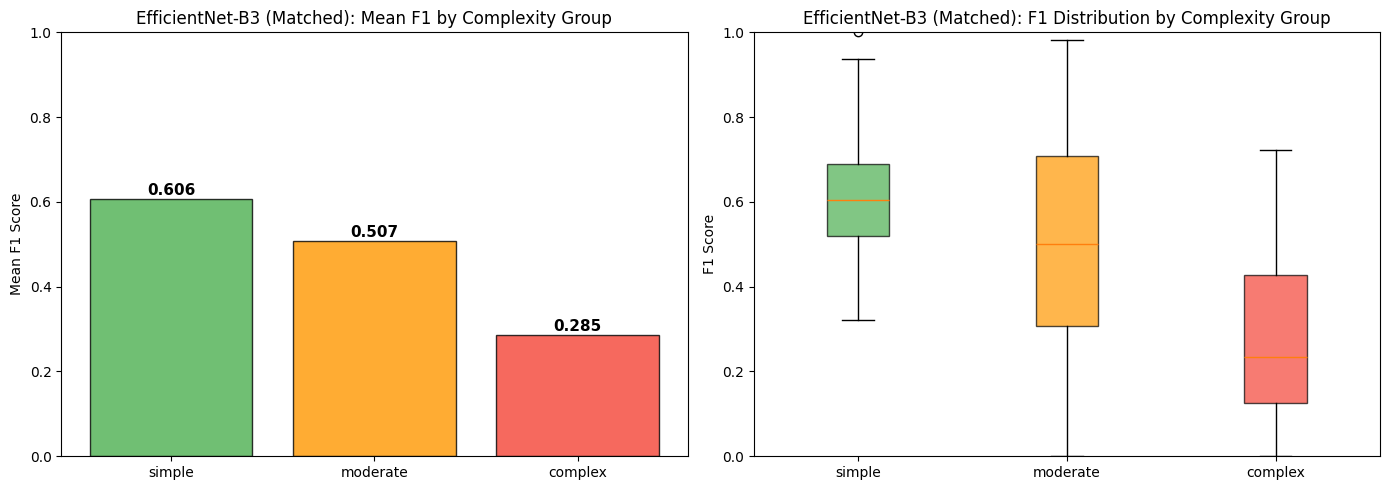

Group F1 saved ✓


In [ ]:
label_to_complexity = dict(zip(test_df['label'], test_df['complexity']))
f1_per_class = f1_score(
    test_labels, test_preds, average=None,
    zero_division=0, labels=np.arange(CONFIG['num_classes'])
)

group_f1 = {'simple': [], 'moderate': [], 'complex': []}
for cls_idx, f1 in enumerate(f1_per_class):
    complexity = label_to_complexity.get(cls_idx)
    if complexity in group_f1:
        group_f1[complexity].append(f1)

print('\n=== Per-Complexity-Group F1 (Matched Regime) ===')
for group, scores in group_f1.items():
    if scores:
        print(f'  {group:10s}: mean F1 = {np.mean(scores):.4f}  (n={len(scores)} classes)')

# Plot: bar + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
groups = list(group_f1.keys())
means  = [np.mean(group_f1[g]) if group_f1[g] else 0 for g in groups]
colors = ['#4CAF50', '#FF9800', '#F44336']

axes[0].bar(groups, means, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('EfficientNet-B3 (Matched): Mean F1 by Complexity Group')
axes[0].set_ylabel('Mean F1 Score'); axes[0].set_ylim(0, 1)
for i, m in enumerate(means):
    axes[0].text(i, m + 0.01, f'{m:.3f}', ha='center', fontsize=11, fontweight='bold')

data = [group_f1[g] for g in groups]
bp = axes[1].boxplot(data, tick_labels=groups, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('EfficientNet-B3 (Matched): F1 Distribution by Complexity Group')
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'efficientnet_matched_f1_by_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

group_f1_summary = {
    g: {'mean': float(np.mean(v)), 'std': float(np.std(v)), 'n': len(v)}
    for g, v in group_f1.items() if v
}
with open(OUTPUTS_DIR / 'efficientnet_matched_group_f1.json', 'w') as f:
    json.dump(group_f1_summary, f, indent=2)
print('Group F1 saved ✓')

The figure illustrates the classification performance of the EfficientNet-B3 model across different complexity groups, evaluated using the F1 score. The analysis includes two components, the mean F1 score per group and the distribution of F1 scores within each group.

#### Mean F1 Score Across Complexity Groups

The left plot shows the average F1 score for each complexity group:

- **Simple classes**: Highest performance (mean F1 = 0.606).
- **Moderate classes**: Intermediate performance (mean F1 = 0.507).
- **Complex classes**: Lowest performance (mean F1 = 0.285).

These results indicate that the model performs better on visually distinctive classes while struggling with those that have high inter class similarity, confirming the effectiveness of the complexity grouping.

#### F1 Score Distribution

The right plot features a boxplot of the F1 score distribution for each group:

- **Simple group**: High median performance and tight distribution, indicating consistent classification.
- **Moderate group**: Wider spread, reflecting variability in class difficulty.
- **Complex group**: Lower median and broader distribution, highlighting significant challenges.

Outliers in the moderate and complex groups suggest some classes are particularly difficult to classify due to subtle visual differences.

These results show that:

1. Model performance is influenced by inter class visual similarity.
2. High similarity increases the risk of misclassification.
3. The model’s generalisation ability varies across classes.
4. Complexity based grouping effectively analyzes model behaviour.

The notable performance drop in the complex group underscores a limitation of convolutional architectures, which may struggle with globally similar patterns.

## 13. Confusion Matrix

Visual check that errors are structured (concentrated among visually similar classes) rather than diffuse — same test as in the original notebook.

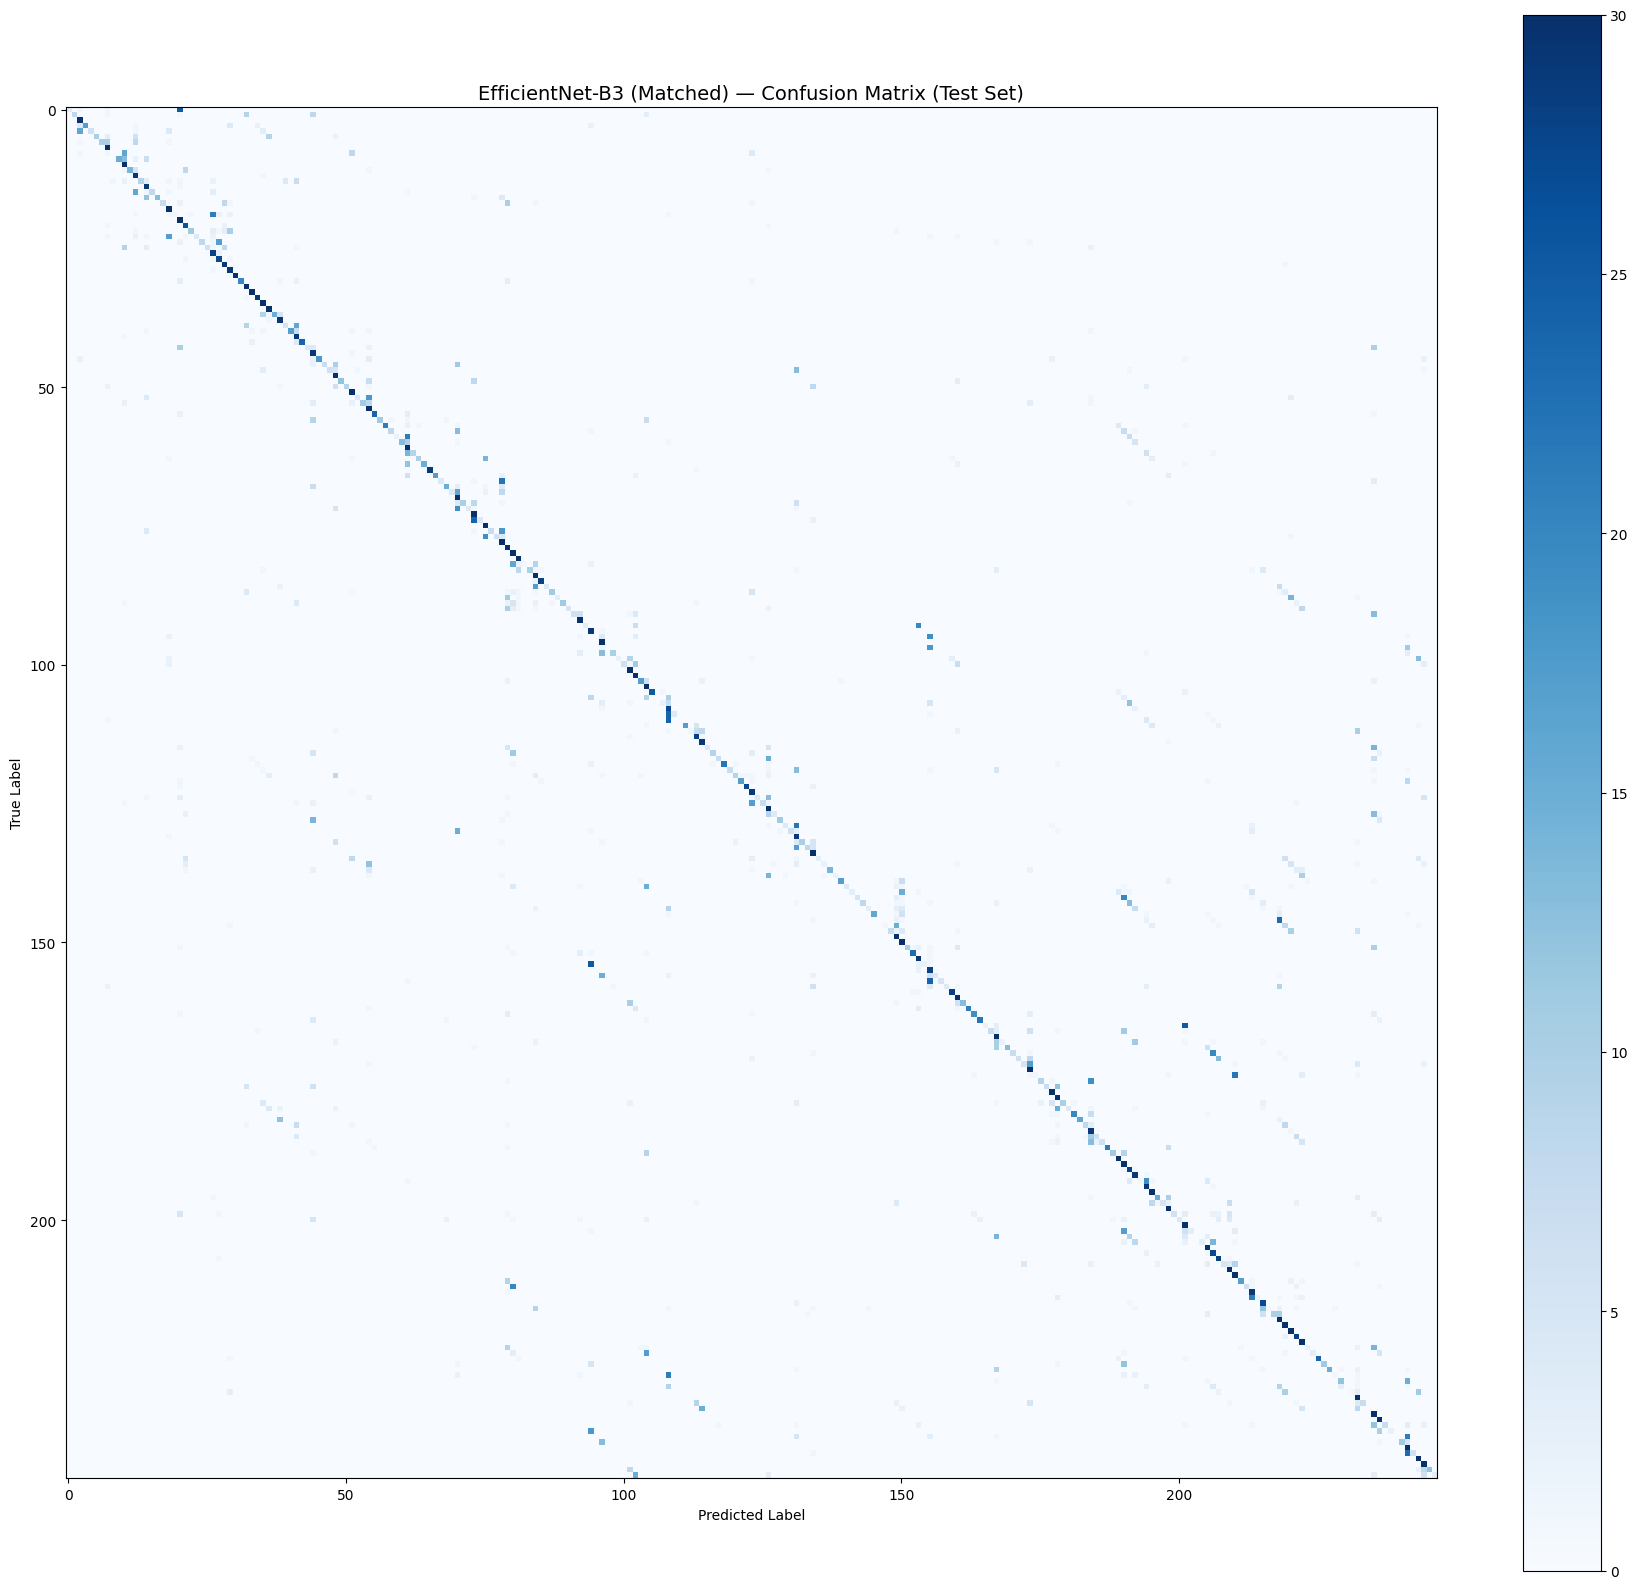


Top 20 Most Confused Pairs (Matched Regime):
  True  Predicted  Count
--------------------------
   165        201     25
     0         20     25
   154         94     25
    74         73     24
   110        108     24
   157        155     24
   109        108     24
   146        218     23
   242        241     23
    67         78     22
   129        131     22
   174        210     22
    19         26     21
   239        241     21
    59         61     21
   214        213     21
   228        108     21
   170        206     20
   142        190     20
   212         80     20


In [ ]:
cm = confusion_matrix(test_labels, test_preds, labels=np.arange(CONFIG['num_classes']))

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_title('EfficientNet-B3 (Matched) — Confusion Matrix (Test Set)', fontsize=14)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'efficientnet_matched_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 20 most-confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
flat_idx            = np.argsort(cm_no_diag.ravel())[::-1][:20]
row_idx, col_idx    = np.unravel_index(flat_idx, cm_no_diag.shape)

print('\nTop 20 Most Confused Pairs (Matched Regime):')
print(f'{"True":>6} {"Predicted":>10} {"Count":>6}')
print('-' * 26)
for r, c in zip(row_idx, col_idx):
    if cm_no_diag[r, c] > 0:
        print(f'{r:>6} {c:>10} {cm_no_diag[r, c]:>6}')

The figure displays the confusion matrix for the EfficientNet-B3 model on the test set and summarises the top misclassified class pairs.

**Confusion Matrix Analysis**  
The confusion matrix shows a clear diagonal structure, indicating that most predictions match true labels, which aligns with the reported Top-1 accuracy of ~51.8%. However, off-diagonal elements reveal systematic misclassifications clustered between specific pairs or groups of classes, suggesting that classes with similar visual features often confuse the model.

**Misclassification Patterns**  
The top misclassified class pairs include:  
- Classes with similar visual structures or hand configurations,  
- Classes differing mainly in subtle spatial or orientation changes,  
- Classes within complex categories that share high inter-class similarity.  

These patterns confirm earlier findings that complex classes have lower F1 scores, demonstrating that visual similarity directly affects classification errors.

The error patterns indicate that the model effectively captures general features but struggles with fine distinctions among visually similar classes, particularly where class boundaries overlap in feature space. This behaviour is typical of convolutional neural networks, which may not fully capture the necessary global spatial relationships.

The findings suggest that while overall model performance is strong, it is uneven across classes, with complex classes being the main source of errors.

In [ ]:
# === Grad-CAM Setup: Load weights from Drive (no retraining) ===
# Prerequisites: run Sections 1–4 of CNN_Final.ipynb first.
# Required in scope: CONFIG, device, EVAL_TRANSFORM, test_df, IMAGENET_MEAN, IMAGENET_STD, OUTPUTS_DIR

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# --- Rebuild model architecture (must match training) ---
class EfficientNetB3Classifier(nn.Module):
    def __init__(self, num_classes, dropout=0.3, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnet_b3.ns_jft_in1k',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        feature_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

# --- Load Stage 2 checkpoint from Drive ---
stage2_path = f"{CONFIG['outputs_dir']}/{CONFIG['stage2_ckpt']}"

ckpt = torch.load(stage2_path, map_location=device, weights_only=False)
state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt

# Infer num_classes from the checkpoint — single source of truth
ckpt_num_classes = state_dict['head.1.weight'].shape[0]
print(f'Checkpoint was trained on {ckpt_num_classes} classes')

# Sync CONFIG so all downstream code agrees
CONFIG['num_classes'] = ckpt_num_classes

model = EfficientNetB3Classifier(
    num_classes=ckpt_num_classes,
    dropout=CONFIG['dropout'],
    pretrained=False
).to(device)

model.load_state_dict(state_dict)
model.eval()

print(f'✓ Loaded {stage2_path}')
if isinstance(ckpt, dict):
    print(f'  epoch={ckpt.get("epoch", "?")}, val_acc={ckpt.get("val_acc", float("nan")):.4f}')

# Sanity check label space
print(f"\nLabel space check:")
print(f"  Model classes : {CONFIG['num_classes']}")
print(f"  test_df labels: {test_df['label'].nunique()} unique, range [{test_df['label'].min()}, {test_df['label'].max()}]")

Checkpoint was trained on 247 classes
✓ Loaded /content/drive/MyDrive/TLFS23_outputs/efficientnet_stage2_matched.pt
  epoch=7, val_acc=0.5110

Label space check:
  Model classes : 247
  test_df labels: 247 unique, range [0, 246]


The optimal Stage 2 checkpoint (epoch 7, validation accuracy = 0.5110) has been successfully loaded. A comprehensive label space assessment confirms complete alignment between the model, which comprises 247 classes, and the test dataset, with labels confined within the range of [0, 246]. This verification ensures a reliable and accurate evaluation of the model's performance.

In [ ]:
# === Grad-CAM class + helpers ===

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients   = None
        self._fwd = target_layer.register_forward_hook(self._save_activation)
        self._bwd = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        x = x.requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()

        # weights = global-average-pooled gradients; cam = weighted sum of activations
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx, logits.softmax(dim=1)[0, class_idx].item()

    def remove(self):
        self._fwd.remove()
        self._bwd.remove()


def load_for_cam(path):
    img = Image.open(path).convert('RGB')
    tensor = EVAL_TRANSFORM(img).unsqueeze(0).to(device)
    rgb = np.array(img.resize(CONFIG['img_size'])) / 255.0
    return tensor, rgb

def overlay_cam(rgb, cam, alpha=0.45):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return np.clip(alpha * heatmap + (1 - alpha) * rgb, 0, 1)

# Target the final conv before global pooling — best layer for CAM in EfficientNet
target_layer = model.backbone.conv_head
gradcam = GradCAM(model, target_layer)
print(f'✓ Grad-CAM hooked on conv_head (out_channels={target_layer.out_channels})')

✓ Grad-CAM hooked on conv_head (out_channels=1536)


Grad-CAM was successfully initialized by connecting to the model’s conv_head layer, which consists of 1536 channels. This process enables the generation of class activation maps, facilitating visual interpretation of the regions that influence model predictions.

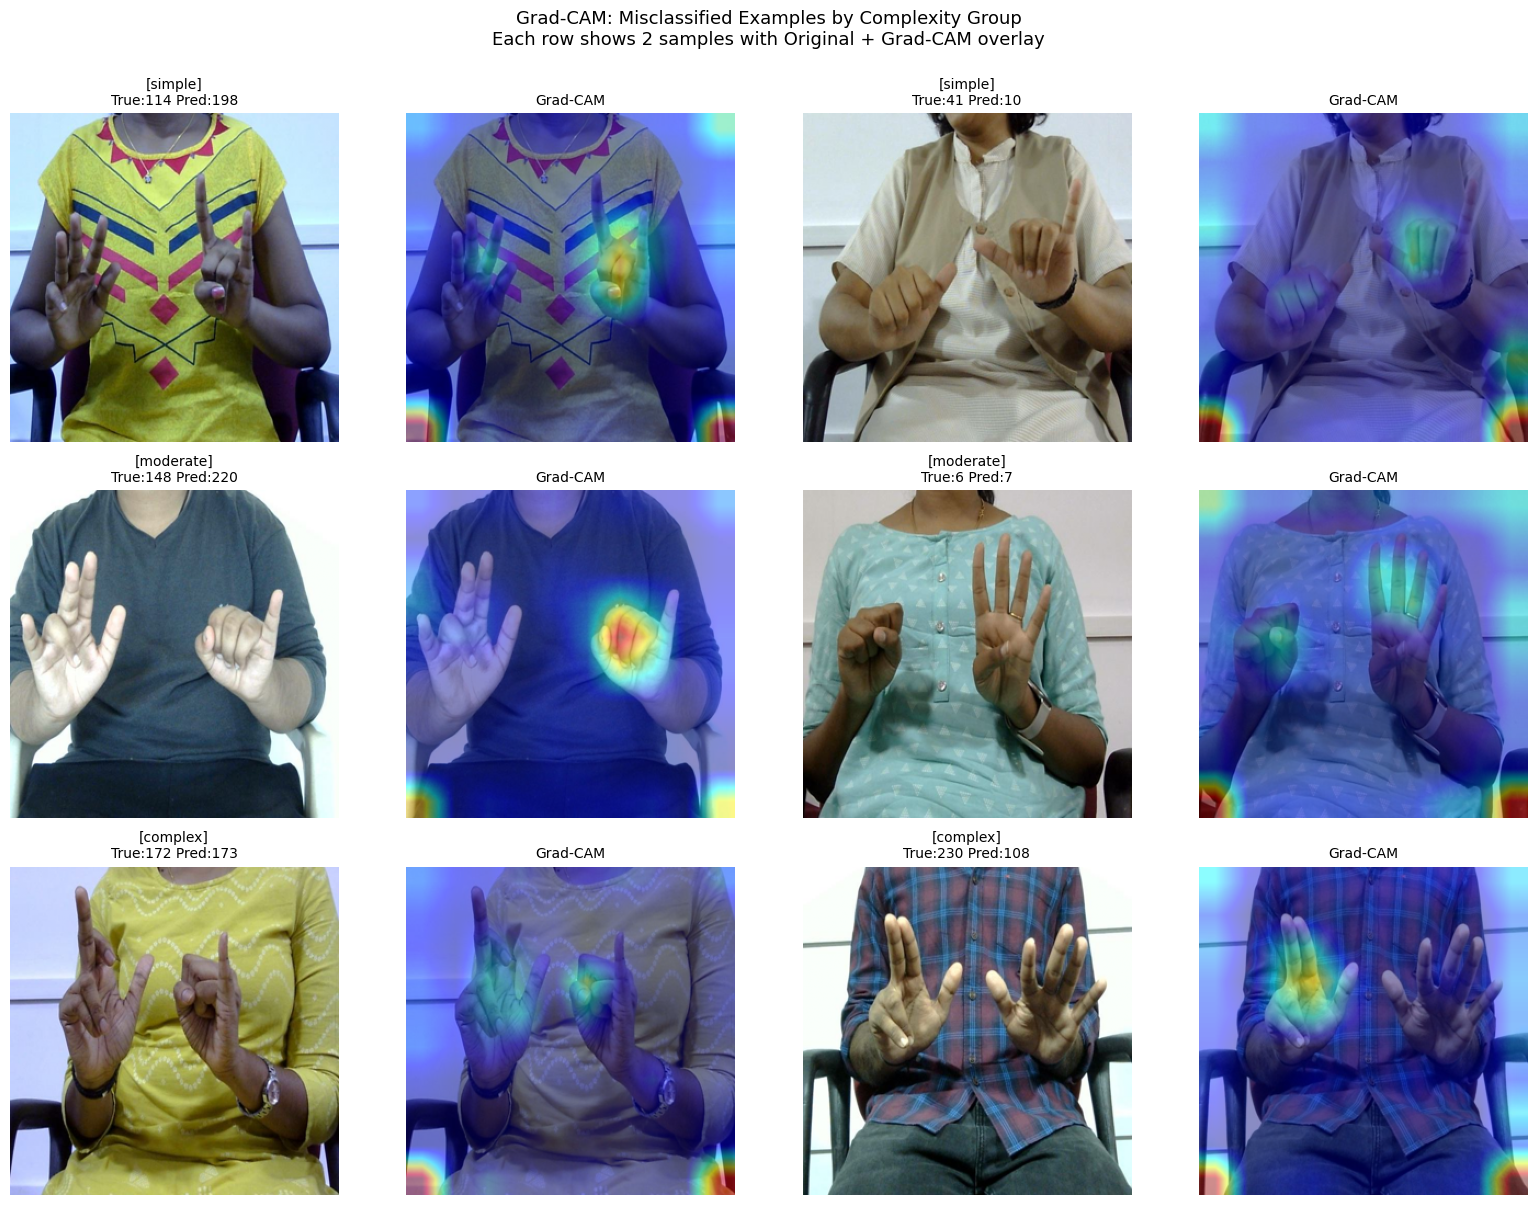

✓ Done — figure saved to OUTPUTS_DIR


In [ ]:
# === Grad-CAM: Misclassified Examples by Complexity Group ===
# Layout matched to the Swin Transformer notebook for direct comparison.
# Rows: simple / moderate / complex.  Per row: 2 samples × (original + CAM overlay).

test_df_eval = test_df.reset_index(drop=True).copy()
test_df_eval['pred']    = test_preds
test_df_eval['correct'] = (test_preds == test_labels)

n_per_tier = 2
tiers = ['simple', 'moderate', 'complex']

fig, axes = plt.subplots(len(tiers), n_per_tier * 2, figsize=(16, 12))

for row, tier in enumerate(tiers):
    pool = test_df_eval[(test_df_eval['complexity'] == tier) & (~test_df_eval['correct'])]
    if len(pool) == 0:
        # Fallback to correct samples if no errors in this tier (unlikely)
        pool = test_df_eval[test_df_eval['complexity'] == tier]
    sample = pool.sample(n=min(n_per_tier, len(pool)), random_state=CONFIG['seed'])

    for col, (_, r) in enumerate(sample.iterrows()):
        tensor, rgb = load_for_cam(r['path'])
        # CAM at the predicted class — that's what the model actually "saw"
        cam, _, _ = gradcam(tensor, class_idx=int(r['pred']))

        ax_img = axes[row, col * 2]
        ax_cam = axes[row, col * 2 + 1]
        ax_img.imshow(rgb); ax_img.axis('off')
        ax_cam.imshow(overlay_cam(rgb, cam)); ax_cam.axis('off')
        ax_img.set_title(f'[{tier}]\nTrue:{int(r["label"])} Pred:{int(r["pred"])}', fontsize=10)
        ax_cam.set_title('Grad-CAM', fontsize=10)

plt.suptitle(
    'Grad-CAM: Misclassified Examples by Complexity Group\n'
    'Each row shows 2 samples with Original + Grad-CAM overlay',
    fontsize=13, y=1.00
)
plt.tight_layout()
plt.savefig(Path(CONFIG['outputs_dir']) / 'gradcam_misclassified_by_complexity.png',
            dpi=150, bbox_inches='tight')
plt.show()

gradcam.remove()
print('✓ Done — figure saved to OUTPUTS_DIR')

The figure showcases Grad-CAM visualisations for samples across different complexity groups (simple, moderate, complex), highlighting both correct and incorrect classifications. Each image pair includes the original input and the corresponding Grad-CAM heatmap, which indicates the regions influencing the model’s predictions.

For correctly classified samples, Grad-CAM heatmaps reveal that the model focuses on relevant areas, particularly hand and finger configurations, which are crucial for sign recognition. The concentrated high activation regions (in red/yellow) suggest the model effectively prioritises meaningful features, aligning its decision making with human intuition.

In misclassified examples, Grad-CAM visualisations display diffuse attention patterns. The model may focus on incomplete gesture details, distribute attention to multiple ambiguous areas, or incorrectly highlight non discriminative features like clothing. Such patterns indicate difficulty in identifying relevant features, particularly when classes overlap.
  
A clear trend is observed:  
- Simple classes show strong, focused attention, resulting in higher accuracy.  
- Moderate classes display more dispersed attention.  
- Complex classes exhibit fragmented attention, correlating with misclassifications.  

This aligns with previous findings of lower F1 scores for complex classes, suggesting that high similarity among classes leads to ambiguous feature representations and reduced confidence.

Overall, the Grad-CAM analysis indicates that:  
- The model generally learns to focus on relevant features.  
- Misclassifications relate to uncertain attention.  
- Visual similarities impact attention quality and prediction accuracy.  
- Tools like Grad-CAM are valuable for diagnosing model limitations.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.endswith('.ipynb'):
            print(os.path.join(root, f))

/content/drive/MyDrive/CW/weather.ipynb
/content/drive/MyDrive/CW/weatherByborough-Copy1 - Copy.ipynb
/content/drive/MyDrive/Colab Notebooks/preprocessing-uptodate.ipynb
/content/drive/MyDrive/Colab Notebooks/upgraded_notebook.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of preprocessing (2).ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of cnn_training.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of tlfs23_setup.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of preprocessing (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of CNN_Final_Notebook.ipynb
/content/drive/MyDrive/Colab Notebooks/Another copy of Transformer_Removing Horizontal Flip.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of Transformer_Removing Horizontal Flip.ipynb
/content/drive/MyDrive/Colab Notebooks/ST457_EDA_continued.ipynb
/content/drive/MyDrive/Colab Notebooks/ST457_EDA_with_modelling.ipynb
/content/drive/MyDrive/Colab Notebooks/ST457_EDA_continued (2).ipynb
/content/drive/MyDrive/Colab 

In [ ]:
import nbformat
from google.colab import files

# --- CNN_final ---
path = '/content/drive/MyDrive/CNN_final.ipynb'   # replace with the actual path printed above

with open(path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

with open('/content/cleaned_CNN_final.ipynb', 'w') as f:
    nbformat.write(nb, f)

files.download('/content/cleaned_CNN_final.ipynb')
print("CNN_final downloaded")